In [1]:

suppressMessages(library(Seurat))
suppressMessages(library(harmony))
suppressMessages(library(ggplot2))
suppressMessages(library(dplyr))
suppressMessages(library(ggraph))
suppressMessages(library(qs))
suppressMessages(library(anndata))
plan("multicore", workers = 128)
options(future.globals.maxSize = 10000000 * 1024^5)
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")



In [2]:
data = read_h5ad("/mnt/90-connectome/Personal/lyw/Human-project/snRNA-seq-data/sn_preprogress/midbrain_qc_doublet-20251216.h5ad")
seurat = CreateSeuratObject(counts = t(data$X), meta.data = data$obs)
seurat

An object of class Seurat 
33317 features across 218772 samples within 1 assay 
Active assay: RNA (33317 features, 0 variable features)
 1 layer present: counts

In [3]:
seurat@meta.data %>% head()

,orig.ident,nCount_RNA,nFeature_RNA,library_id,task_id,sample_id,main_structure,area,source,countFeatureRatio,percent.mt,doublet_score_dbr05,doublet_class_dbr05
,<fct>,<dbl>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>
human-103_CELL2_N2,human-103,7789.719,4514,human-103,W202509180022292,H20241213-L5A-052,midbrain,mb-RN,4,1.725680,0.416461409,7.133153e-06,singlet
human-103_CELL4_N4,human-103,6433.808,3515,human-103,W202509180022292,H20241213-L5A-052,midbrain,mb-RN,4,1.830386,0.002724363,4.531323e-07,singlet
human-103_CELL7_N3,human-103,6989.702,3548,human-103,W202509180022292,H20241213-L5A-052,midbrain,mb-RN,4,1.970040,0.000000000,4.502822e-07,singlet
human-103_CELL13_N3,human-103,5880.457,3166,human-103,W202509180022292,H20241213-L5A-052,midbrain,mb-RN,4,1.857377,0.000000000,4.612048e-07,singlet
human-103_CELL15_N3,human-103,12747.180,5053,human-103,W202509180022292,H20241213-L5A-052,midbrain,mb-RN,4,2.522695,0.000000000,3.231048e-07,singlet
human-103_CELL16_N2,human-103,10765.215,4804,human-103,W202509180022292,H20241213-L5A-052,midbrain,mb-RN,4,2.240886,0.000000000,1.729593e-06,singlet


In [33]:
seurat$source %>% unique()

[1] 4 5 6 7
Levels: 4 5 6 7

In [3]:
Idents(seurat) = ""
seurat_sub = subset(seurat, downsample = 50000)
seurat_sub

An object of class Seurat 
33317 features across 50000 samples within 1 assay 
Active assay: RNA (33317 features, 0 variable features)
 1 layer present: counts

In [35]:

M1_data_sub_1 <- seurat_sub %>% 
    # NormalizeData(normalization.method = "LogNormalize") %>% 
    # FindVariableFeatures( nfeatures = 10000) %>% 
    # ScaleData() %>% 
    SCTransform(variable.features.n = 2000, vars.to.regress = "percent.mt") %>% 
    RunPCA(npcs=100,verbose = FALSE) 

M1_data_sub_2 <- M1_data_sub_1 %>% 
    # FindNeighbors(dims = 1:40) %>%
    # FindClusters(verbose = FALSE, resolution = 1.5, random.seed = 666) %>%
    RunUMAP(dims = 1:50, seed.use = 666, umap.method = "umap-learn",min.dist = 0.2,n.neighbors = 50)

# M1_data_sub_3 = RunHarmony(
#     M1_data_sub_2, group.by.vars=c("Animal"), plot_convergence=T,
#     reduction.save = "harmony", dims.use=1:5,
#     theta=2)

# M1_data_sub_4 <- M1_data_sub_3 %>%
#     FindNeighbors(reduction="harmony", dims = 1:5,k.param = 50) %>%
#     FindClusters(verbose = FALSE,resolution = 0.4, random.seed = 666) %>%
#     RunUMAP(reduction="harmony", dims = 1:5,min.dist = 0.5)


Running SCTransform on assay: RNA



vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 30399 by 50000

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells

There are 155 estimated thetas smaller than 1e-07 - will be set to 1e-07

Found 1 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 30399 genes

Computing corrected count matrix for 30399 genes

Calculating gene attributes

Wall clock passed: Time difference of 11.3505 mins

Determine variable features

Regressing out percent.mt

Centering data matrix

Place corrected count matrix in counts slot

Set default assay to SCT



In [47]:
M1_data_sub_2 <- M1_data_sub_2 %>% 
    # FindNeighbors(dims = 1:40) %>%
    # FindClusters(verbose = FALSE, resolution = 1.5, random.seed = 666) %>%
    RunUMAP(dims = 1:60, seed.use = 777, umap.method = "umap-learn",min.dist = 0.5,n.neighbors = 150)

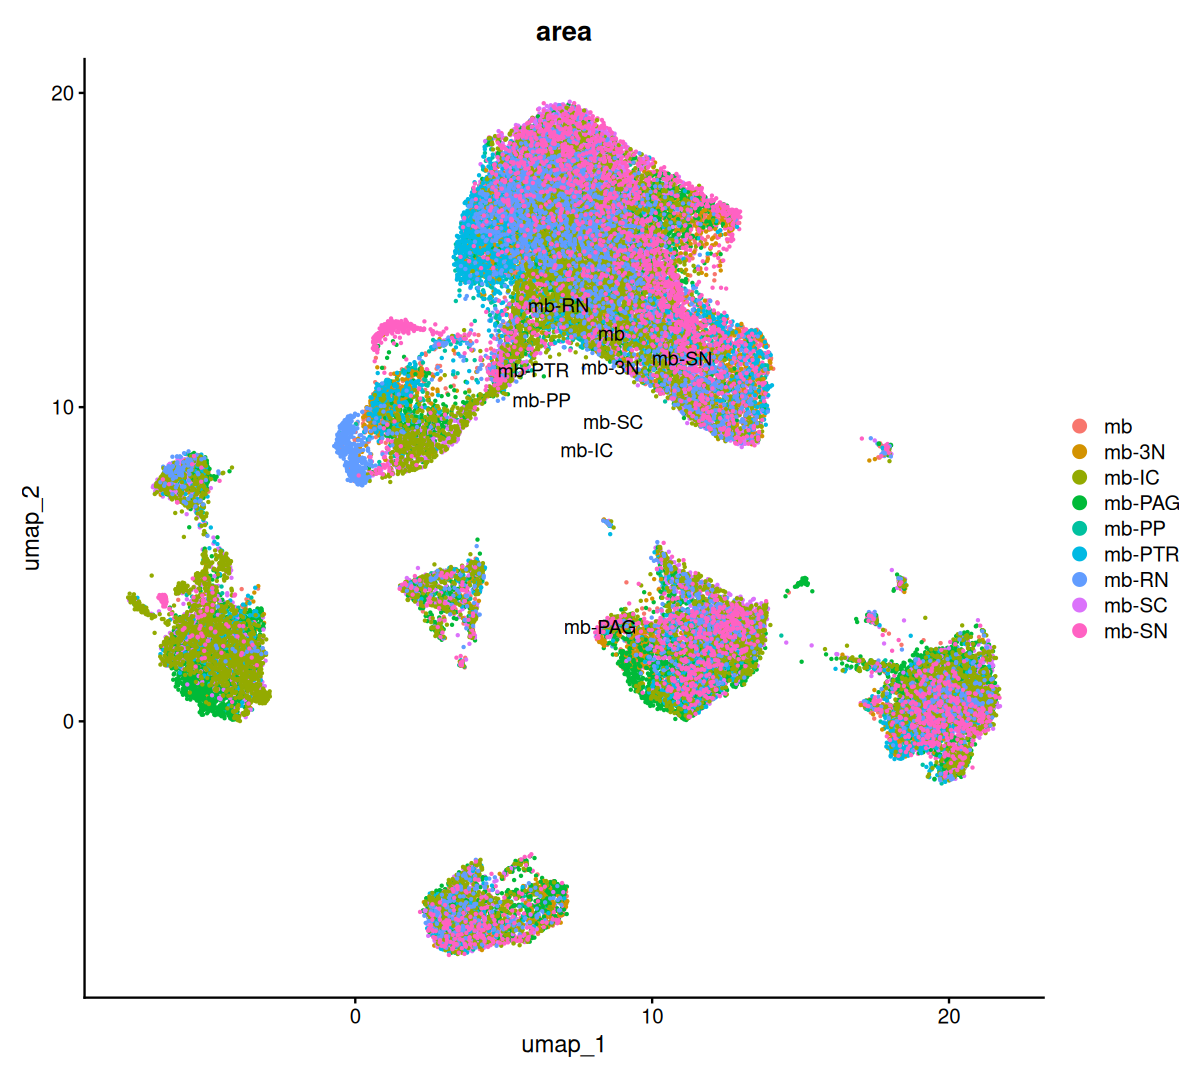

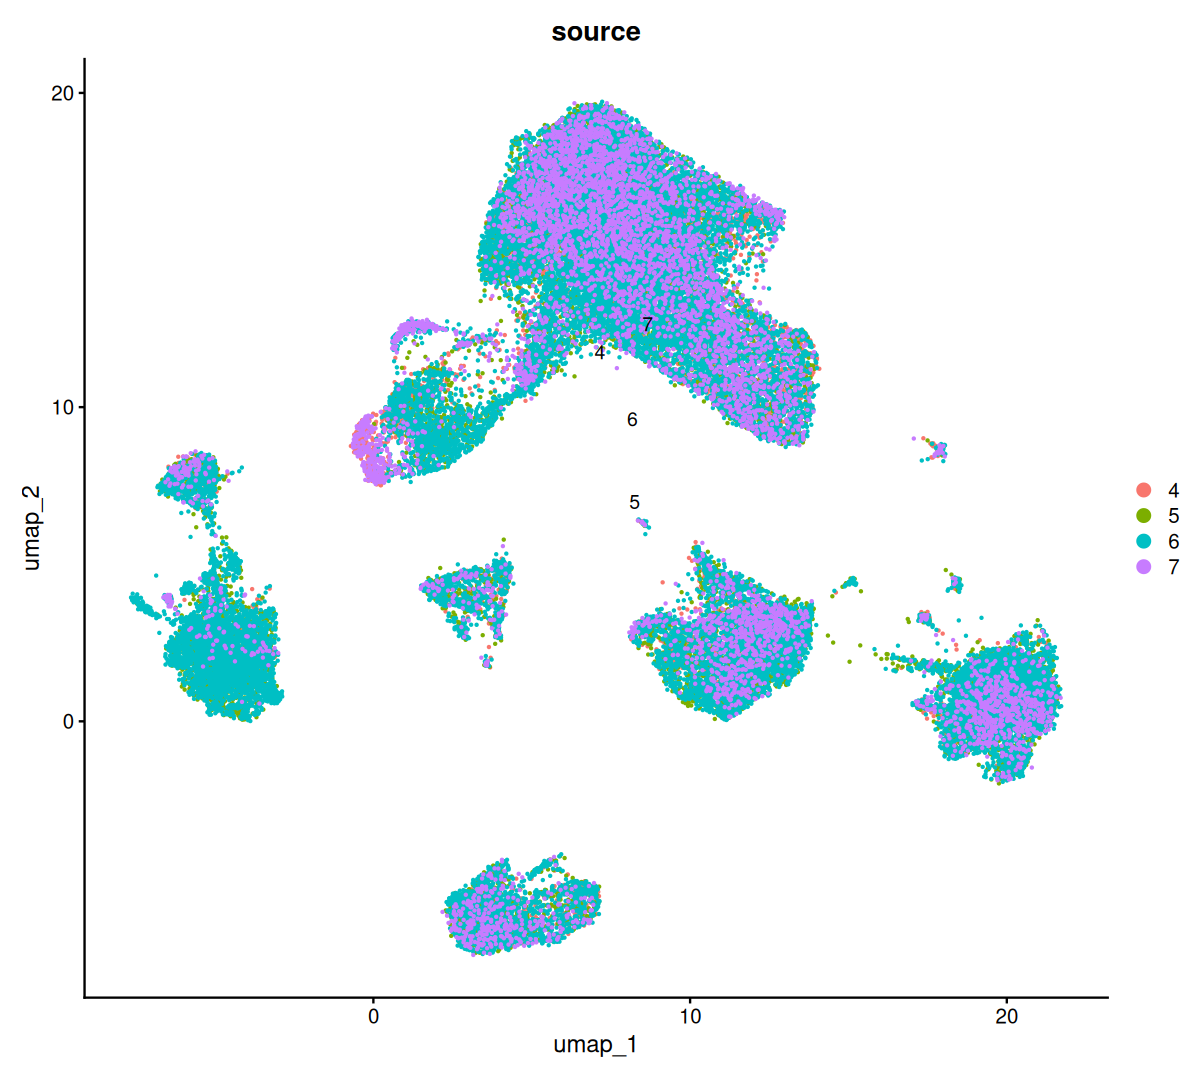

In [48]:
options(repr.plot.width = 10, repr.plot.height = 9)
# Idents(M1_data_sub_2) = "area"
DimPlot(M1_data_sub_2, reduction = "umap", label = TRUE, repel = TRUE, group.by = "area")
DimPlot(M1_data_sub_2, reduction = "umap", label = TRUE, repel = TRUE, group.by = "source")

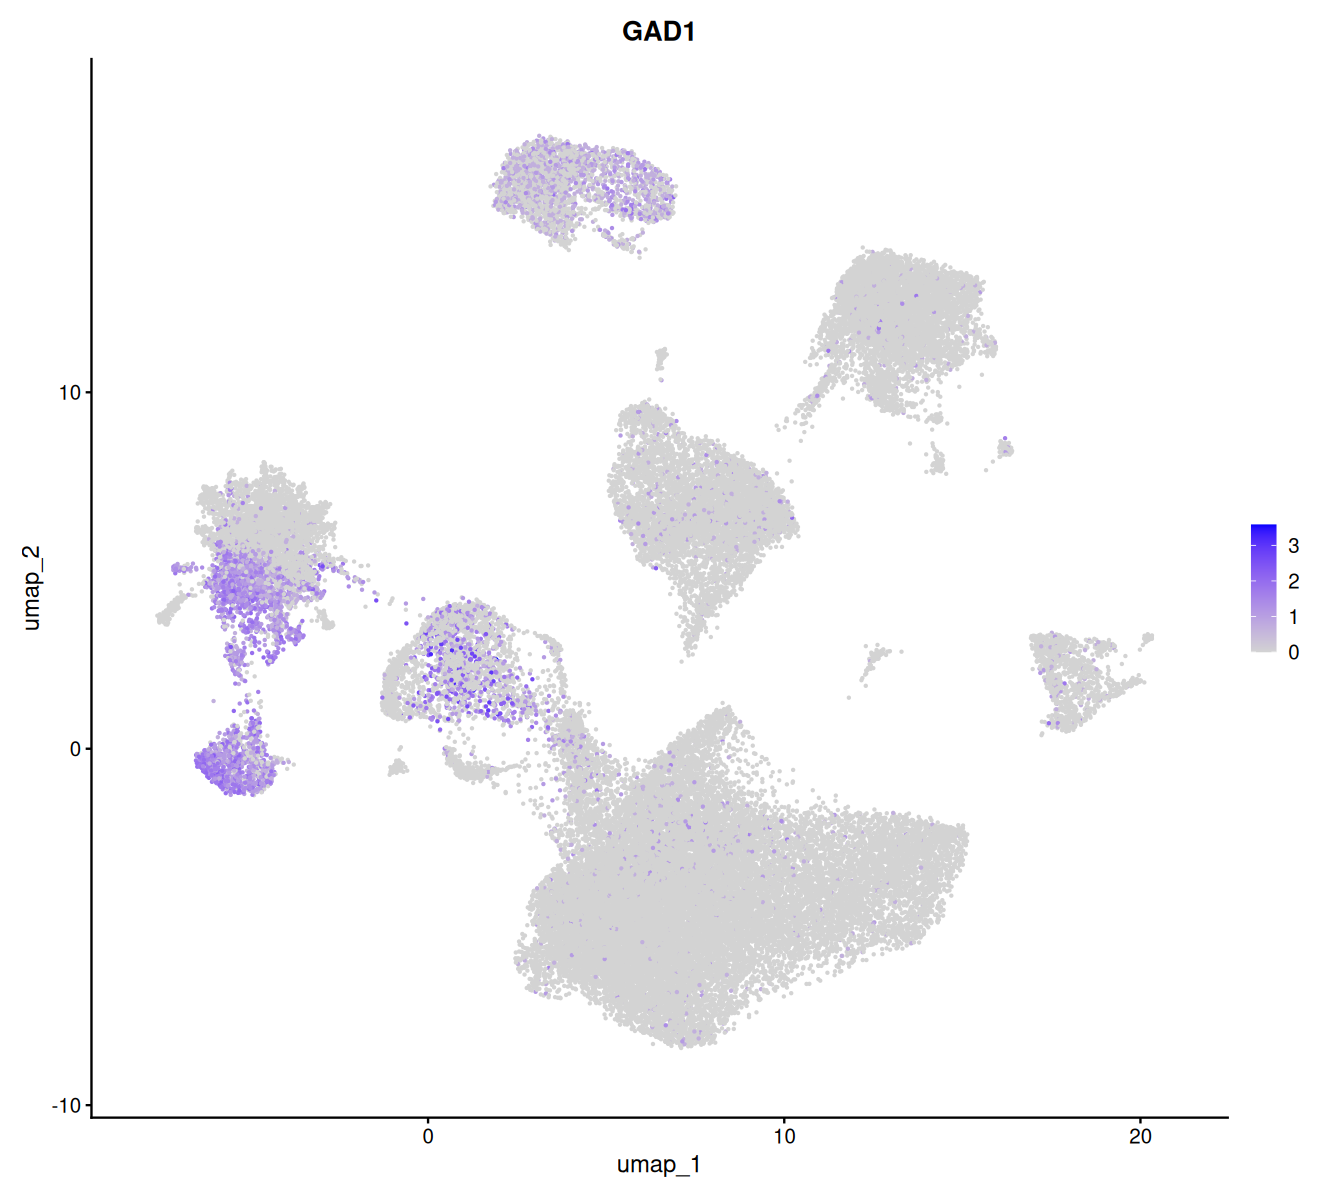

In [43]:
options(repr.plot.width = 11, repr.plot.height = 10)
FeaturePlot(M1_data_sub_2, features = "GAD1")

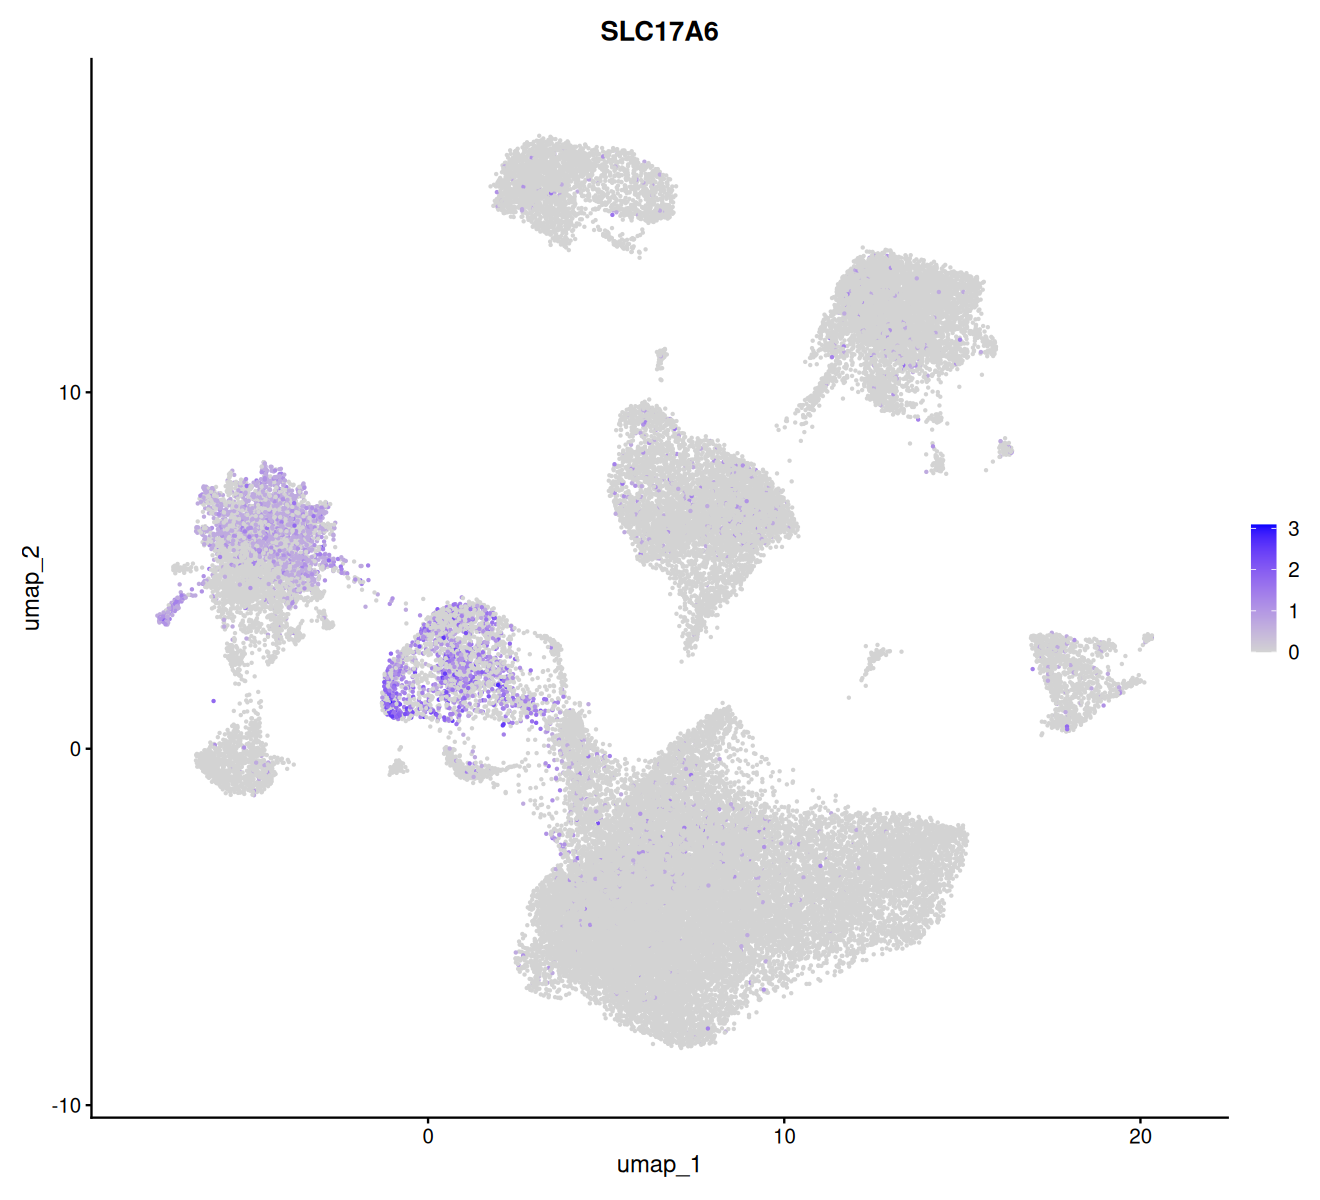

In [44]:
FeaturePlot(M1_data_sub_2, features = "SLC17A6")